
# Analyse Prédictive des Revenus des Pièces Détachées pour Motocycles

## Contexte du Projet
L'entreprise pour laquelle nous travaillons vend des pièces de moto et possède trois entrepôts situés dans différentes régions. Elle vend à la fois aux clients de détail (Retail) et aux clients en gros (Wholesale).

L'entreprise accepte plusieurs modes de paiement (carte de crédit, espèces et virement bancaire), mais chaque méthode entraîne des frais de transaction différents.

Le conseil d'administration souhaite mieux comprendre les revenus générés par les ventes en gros en fonction des lignes de produits, des mois et des entrepôts.

## Objectif du Projet
Nous devons calculer le revenu net des ventes en gros, c'est-à-dire :

**Revenu Net = Revenu Total − Frais de paiement**

Les résultats doivent être regroupés par ligne de produit, par mois et par entrepôt, et seuls les clients Wholesale doivent être pris en compte.

## Structure de la Base de Données
L'entreprise nous a donné accès à une base de données PostgreSQL contenant une table appelée sales avec les informations suivantes :

| Column | Data type | Description |
|--------|-----------|-------------|
| `order_number` | `VARCHAR` | Numero unique de commande. |
| `date` | `DATE` | Date de la commande (entre juin et aout 2021). |
| `warehouse` | `VARCHAR` | Entrepôt d'où provient la commande ( `North`, `Central`, ou `West`. |
| `client_type` | `VARCHAR` | Type de client `Retail` ou `Wholesale`. |
| `product_line` | `VARCHAR` | Type de produit commandé. |
| `quantity` | `INT` | Nombre d’unités commandées. | 
| `unit_price` | `FLOAT` | Prix unitaire du produit (en dollars). |
| `total` | `FLOAT` | Prix total de la commande (en dollars). |
| `payment` | `VARCHAR` | Mode de paiement (`Credit card`, `Transfer`, or `Cash`). |
| `payment_fee` | `FLOAT` | Frais de paiement appliqués (en % du total).. |



## Configuration de la connexion à la base de données
- Connexion à **PostgreSQL** avec **psycopg2** et **sqlalchemy**.
- Vérification de la connexion pour s'assurer que tout fonctionne.
- Exécution d'une requête **SQL** pour extraire des données.
- Chargement des données dans Pandas pour une manipulation facile.
- Affichage des résultats pour une première exploration.


In [130]:
import pandas as pd
import psycopg2
from sqlalchemy import create_engine

# Informations de connexion
DB_NAME = "motorcycle_sales"   
DB_USER = "postgres"          
DB_PASSWORD = "medarine672"       
DB_HOST = "localhost"          
DB_PORT = "5432"               

# Connexion avec SQLAlchemy
DATABASE_URL = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(DATABASE_URL)

# Vérifier la connexion
try:
    conn = psycopg2.connect(
        dbname=DB_NAME,
        user=DB_USER,
        password=DB_PASSWORD,
        host=DB_HOST,
        port=DB_PORT
    )
    print("Connexion réussie à PostgreSQL !")
except Exception as e:
    print("Erreur de connexion :", e)

# Charger les données de la table sales dans un DataFrame pandas
query = "SELECT * FROM sales;"  
df = pd.read_sql(query, engine)
df1 = pd.read_sql(query, engine)
# Afficher les 10 premières lignes du DataFrame pour vérifier que tout est chargé
print(df1.head(10))


Connexion réussie à PostgreSQL !
  order_number        date warehouse client_type           product_line  \
0           N1  2021-06-01     North      Retail         Braking system   
1           N2  2021-06-01     North      Retail  Suspension & traction   
2           N3  2021-06-01     North   Wholesale           Frame & body   
3           N4  2021-06-01     North   Wholesale  Suspension & traction   
4           N5  2021-06-01     North      Retail           Frame & body   
5           N6  2021-06-02     North      Retail           Frame & body   
6           N7  2021-06-02     North      Retail          Miscellaneous   
7           N8  2021-06-03     North      Retail      Electrical system   
8           N9  2021-06-03     North      Retail  Suspension & traction   
9          N10  2021-06-03     North      Retail      Electrical system   

   quantity  unit_price    total      payment  payment_fee  
0         9       19.29   173.61         Cash         0.00  
1         8       3



## Explication de la Requête SQL
Dans ce code, nous effectuons une analyse des ventes mensuelles par produit, entrepôt, et type de client pour déterminer le revenu net pour chaque ligne de produit et pour chaque entrepôt. Le processus se déroule en deux grandes étapes :

### Calcul des ventes mensuelles avec des sous-totaux par entrepôt et par produit.
### Calcul du revenu net en soustrayant les frais de paiement.

- **WITH monthly_sales AS (...)**:
Cette partie du code est une **Common Table Expression (CTE)**, qui permet de créer une sous-requête temporaire appelée monthly_sales. Une fois cette sous-requête définie, elle peut être utilisée dans la suite de la requête principale.
Cette sous-requête permet de calculer les ventes mensuelles pour chaque ligne de produit (**product_line**) et pour chaque entrepôt (**warehouse**), en filtrant les données uniquement pour les commandes de type "Wholesale" (gros clients).

- **TO_CHAR(date, 'Month') AS month** :
La fonction **TO_CHAR()** permet de formater la date sous forme de mois (par exemple, janvier, février, etc.), en l'attribuant à une nouvelle colonne appelée **month**.


- **SUM(total) AS total_revenue, SUM(payment_fee) AS total_fees**:
Ces lignes calculent le revenu total pour chaque ligne de produit et entrepôt, ainsi que les frais de paiement associés. La somme des valeurs de la colonne total donne le revenu, et la somme des valeurs de payment_fee donne les frais de paiement.


- **GROUP BY product_line, month, warehouse**:
Cette clause permet de regrouper les résultats par ligne de produit, mois, et entrepôt. Cela signifie que pour chaque combinaison de ces trois colonnes, une ligne distincte sera créée avec les sommes des revenus et des frais.
Après avoir défini cette CTE, on l'utilise dans la requête principale pour calculer le revenu net :


In [161]:
###Start coding here
query = """
WITH monthly_sales AS (
    SELECT 
        product_line,
        TO_CHAR(date, 'Month') AS month,
        warehouse,
        SUM(total) AS total_revenue,
        SUM(payment_fee) AS total_fees
    FROM sales
    WHERE client_type = 'Wholesale'
    GROUP BY product_line, month, warehouse
)
SELECT 
    product_line,
    TRIM(month) AS month,
    warehouse,
    (total_revenue - total_fees) AS net_revenue
FROM monthly_sales
ORDER BY product_line, month, net_revenue DESC;
"""

# Charger les données dans un DataFrame Pandas
df = pd.read_sql(query, engine)

# Vérifier les 5 premières lignes
print(df.head())

     product_line     month warehouse  net_revenue
0  Braking system  December   Central      7547.50
1  Braking system  December     North      2893.99
2  Braking system  December      West       842.89
3  Braking system   January      West     18042.57
4  Braking system   January     North      6037.41




## Installation de pandas sqlalchemy psycopg2 matplotlib seaborn 

In [ ]:
conda install pandas sqlalchemy psycopg2 matplotlib seaborn


## Visualisation des resultats
Ce code utilise les bibliothèques **matplotlib** et **seaborn** pour créer un graphique en barres qui visualise les revenus nets par ligne de produit. Voici une explication détaillée de chaque partie du code :

- **matplotlib.pyplot (plt)**: Cette bibliothèque est utilisée pour créer des graphiques en Python. Ici, plt est un alias couramment utilisé pour cette bibliothèque.
- **seaborn (sns)**: Seaborn est une extension de matplotlib qui permet de créer des graphiques statistiques plus facilement et avec un style plus attrayant. Il est utilisé ici pour générer un graphique en barres.



### a. Revenus nets par ligne de produit

/tmp/ipykernel_54831/1939107464.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="product_line", y="net_revenue", estimator=sum, ci=None, palette="Blues_d")
/tmp/ipykernel_54831/1939107464.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="product_line", y="net_revenue", estimator=sum, ci=None, palette="Blues_d")


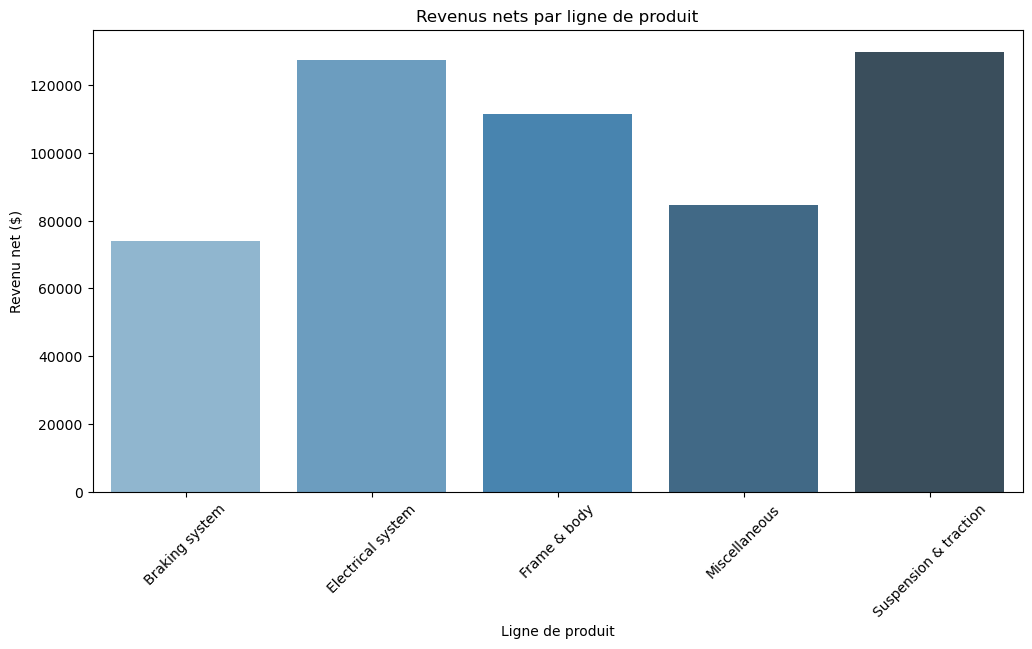

In [163]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.barplot(data=df, x="product_line", y="net_revenue", estimator=sum, ci=None, palette="Blues_d")
plt.xticks(rotation=45)
plt.xlabel("Ligne de produit")
plt.ylabel("Revenu net ($)")
plt.title("Revenus nets par ligne de produit")
plt.show()

### b. Évolution des revenus par mois
Ce graphique permet d'analyser la tendance des revenus nets de chaque ligne de produit au cours des mois, afin d'identifier les périodes de croissance ou de baisse- 

- **plt.figure(figsize=(12,6))**
Définit la taille de la figure (12 pouces de large, 6 pouces de haut).

- **sns.lineplot(...)**
Utilise la fonction lineplot() de Seaborn pour tracer des courbes.

- **data=df** : Utilisation du DataFrame df contenant les données.
- **x="month"** : L’axe X représente les mois.
- **y="net_revenue"** : L’axe Y représente le revenu net.
- **hue="product_line"** : Différencie les lignes selon la ligne de produit.
- **marker="o"** : Ajoute un marqueur circulaire sur chaque point des courbes.
- **palette="tab10"** : Utilise une palette de couleurs pour distinguer les produits.

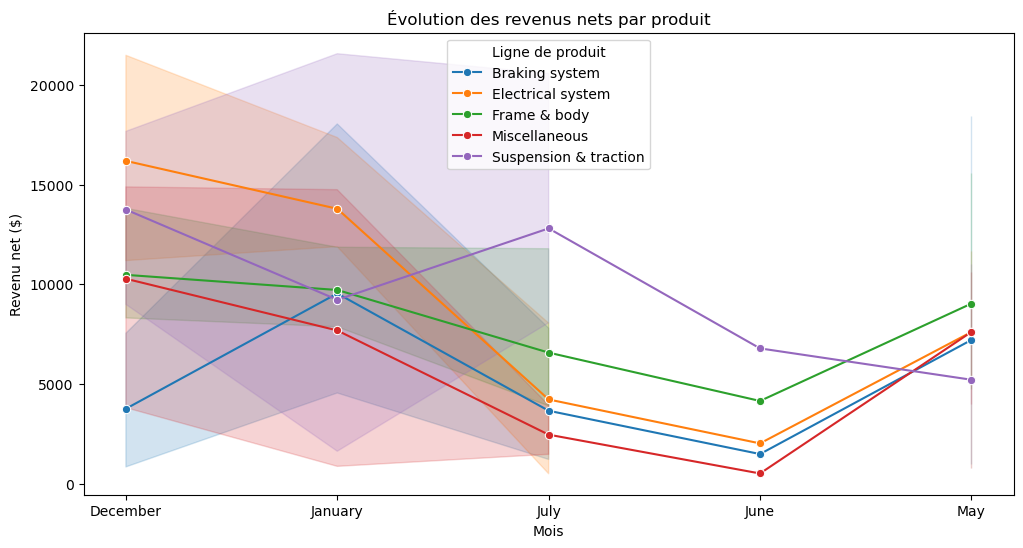

In [113]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x="month", y="net_revenue", hue="product_line", marker="o", palette="tab10")
plt.xlabel("Mois")
plt.ylabel("Revenu net ($)")
plt.title("Évolution des revenus nets par produit")
plt.legend(title="Ligne de produit")
plt.show()




### c. Revenus nets par entrepôt

Ce graphique en boîte à moustaches (boxplot) permet d’analyser la distribution des revenus nets des commandes selon les entrepôts (Central, North et West). Il met en évidence les tendances centrales (médiane), la dispersion des valeurs et la présence d’éventuelles commandes atypiques (outliers).

#### Interprétation du boxplot

1️⃣ **Médiane des revenus**
- L’entrepôt West a la médiane la plus élevée, indiquant que ses commandes génèrent en moyenne les revenus les plus importants.
- L’entrepôt North possède une médiane intermédiaire, suggérant des revenus moyens par commande.
- L’entrepôt Central affiche la médiane la plus basse, ce qui signifie que ses commandes rapportent généralement moins que celles des autres entrepôts.
  
2️⃣ **Dispersion des revenus**
- West a la plus grande boîte → forte variabilité des revenus, ce qui signifie que certaines commandes rapportent beaucoup plus que d’autres.
- North a une boîte de taille moyenne → les revenus sont plus homogènes que ceux de West mais restent plus dispersés que ceux de Central.
- Central a la boîte la plus petite → faible variabilité des revenus, les commandes ont généralement des montants similaires.
  
3️⃣ **Présence d’outliers**
- North présente un outlier (une commande exceptionnelle avec un revenu très élevé).
- West et Central ne présentent aucun outlier, ce qui signifie que leurs revenus sont relativement constants.
- 
#### Conclusions et recommandations
- L’entrepôt West génère les commandes les plus rentables mais avec une forte variabilité, nécessitant une gestion optimisée des stocks et des ressources.
- L’entrepôt North a un revenu moyen stable avec une commande exceptionnelle, ce qui pourrait indiquer une opportunité à explorer (ex. produit phare ou client important).
- L’entrepôt Central a les revenus les plus faibles et les plus constants, ce qui suggère un modèle stable mais potentiellement moins performant en termes de rentabilité. 

/tmp/ipykernel_54831/2174979725.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="warehouse", y="net_revenue", palette="Set2")


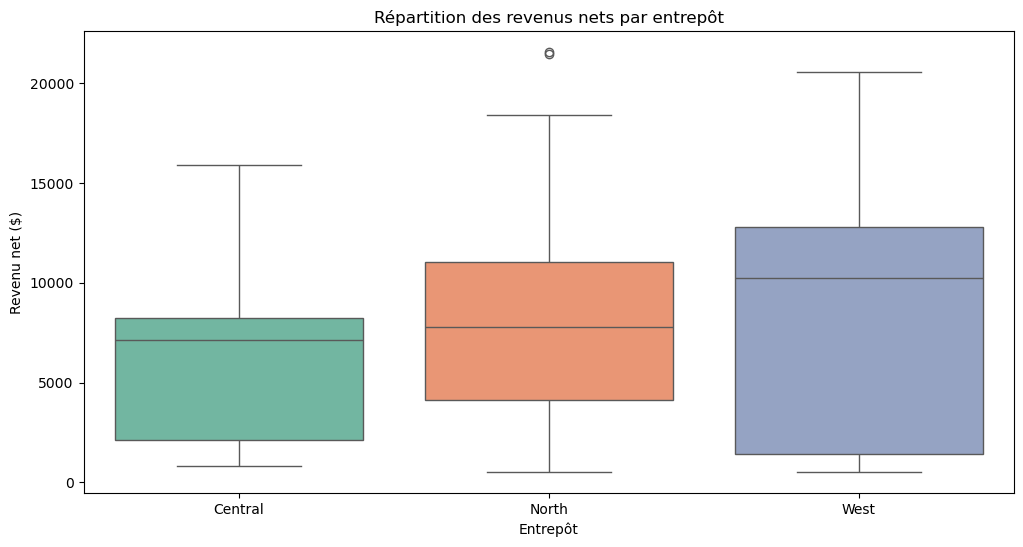

In [115]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="warehouse", y="net_revenue", palette="Set2")
plt.xlabel("Entrepôt")
plt.ylabel("Revenu net ($)")
plt.title("Répartition des revenus nets par entrepôt")
plt.show()


In [101]:
# import pandas as pd

# # Charger les données du fichier CSV
# df = pd.read_csv("sales_data_jan_dec.csv")

# # Vérifier les doublons basés sur la colonne order_number
# duplicates = df[df.duplicated(subset=["order_number"], keep=False)]

# # Afficher les doublons s'il y en a
# if not duplicates.empty:
#     print("Doublons détectés :")
#     print(duplicates)
# else:
#     print("Aucun doublon détecté.")


Doublons détectés :
     order_number        date warehouse client_type           product_line  \
100        N11200   2021-01-4      West   Wholesale      Electrical system   
101        N11201  2021-01-28     North      Retail          Miscellaneous   
102        N11202  2021-01-13     North   Wholesale      Electrical system   
103        N11203  2021-01-21     North      Retail      Electrical system   
104        N11204   2021-01-3     North      Retail         Braking system   
...           ...         ...       ...         ...                    ...   
2095       N12295   2021-12-4      West      Retail      Electrical system   
2096       N12296  2021-12-20      West   Wholesale           Frame & body   
2097       N12297  2021-12-17      West   Wholesale      Electrical system   
2098       N12298  2021-12-19      West   Wholesale  Suspension & traction   
2099       N12299  2021-12-12   Central   Wholesale           Frame & body   

      quantity  unit_price    total      pa

In [103]:
# import pandas as pd

# # Charger les données
# df = pd.read_csv("sales_data_jan_dec.csv")

# # Supprimer les doublons en gardant seulement la première occurrence
# df = df.drop_duplicates(subset=["order_number"], keep=False)

# # Générer de nouveaux order_number uniques pour les lignes supprimées
# existing_order_numbers = set(df["order_number"])  # Stocker les valeurs existantes

# def generate_unique_order_number(index):
#     while True:
#         new_order = f"N1{index:04d}"  # Format : N1XXXX
#         if new_order not in existing_order_numbers:
#             existing_order_numbers.add(new_order)
#             return new_order

# # Appliquer un nouveau order_number pour les doublons supprimés
# df.loc[df["order_number"].duplicated(keep=False), "order_number"] = [
#     generate_unique_order_number(i) for i in range(len(df))
# ]

# # Sauvegarder le fichier nettoyé
# df.to_csv("sales_data_jan_dec_clean.csv", index=False)
# print("Fichier nettoyé et enregistré sous 'sales_data_jan_dec_clean.csv'.")


Fichier nettoyé et enregistré sous 'sales_data_jan_dec_clean.csv'.


## Visualisation supplementaire
### a. Histogramme des quantités commandées
**Objectif** : Visualiser la répartition du nombre d’unités commandées pour détecter les tendances et les valeurs extrêmes.

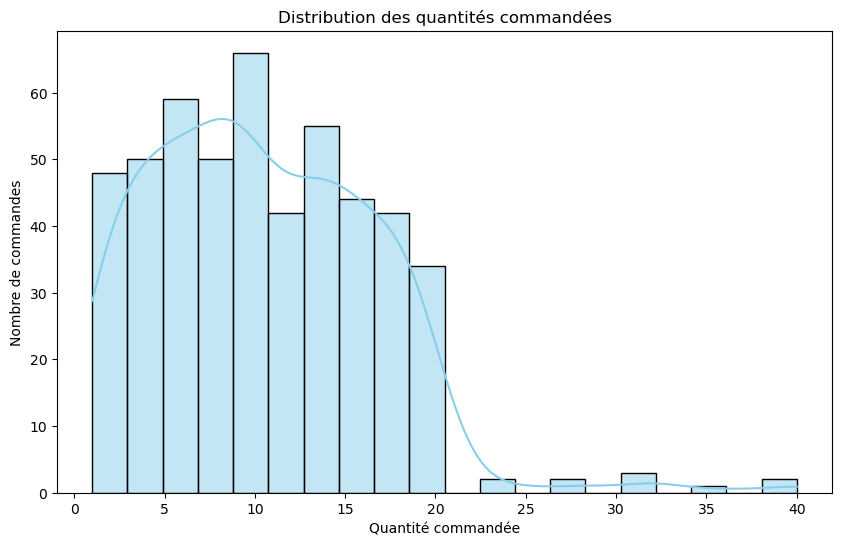

In [134]:
plt.figure(figsize=(10,6))
sns.histplot(df1["quantity"], bins=20, kde=True, color="skyblue")
plt.xlabel("Quantité commandée")
plt.ylabel("Nombre de commandes")
plt.title("Distribution des quantités commandées")
plt.show()


### b.  Diagramme circulaire (Pie Chart) des types de clients
**Objectif** : Voir la répartition entre les clients Retail et Wholesale.



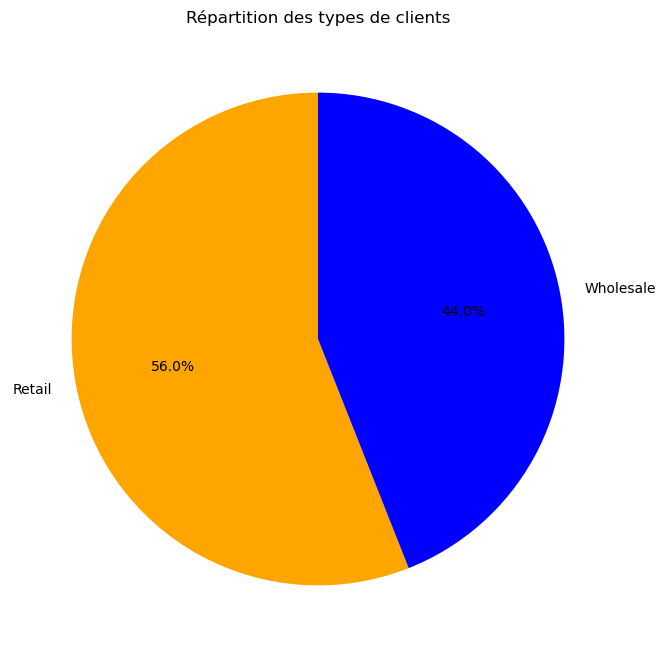

In [151]:
plt.figure(figsize=(8,8))
df1["client_type"].value_counts().plot.pie(autopct="%1.1f%%", colors=["orange", "blue"], startangle=90)
plt.title("Répartition des types de clients")
plt.ylabel("")  # Cache l'étiquette de l'axe Y
plt.show()


### Boxplot des prix unitaires par ligne de produit
**Objectif** : Comparer la variabilité des prix unitaires entre les différentes catégories de produits.

**Interprétation attendue** :
- Permet de voir quelle gamme de produits est la plus chère.
- Une gamme avec une forte variabilité de prix peut indiquer une offre diversifiée (différentes qualités de produits).

/tmp/ipykernel_54831/3503008886.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df1, x="product_line", y="unit_price", palette="Set3")


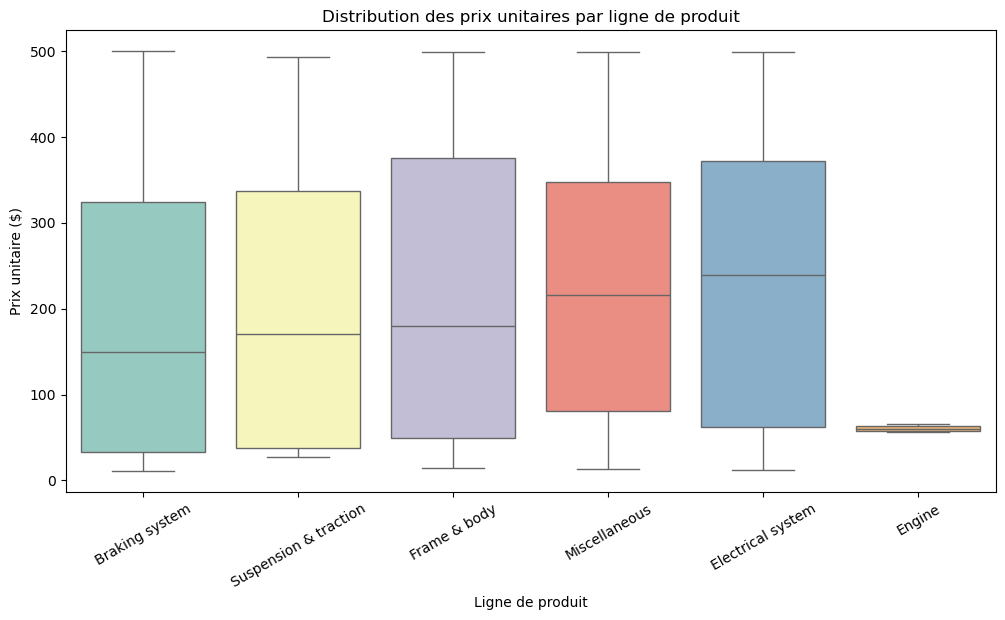

In [153]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df1, x="product_line", y="unit_price", palette="Set3")
plt.xlabel("Ligne de produit")
plt.ylabel("Prix unitaire ($)")
plt.title("Distribution des prix unitaires par ligne de produit")
plt.xticks(rotation=30)
plt.show()


### Évolution des revenus nets au fil du temps
#### **Objectif** : 
- Observer comment les revenus évoluent de mois en mois.
#### **Interprétation attendue** :
- Permet d’identifier des périodes de forte activité et des baisses potentielles.
- Une analyse des pics pourrait aider à planifier des stratégies marketing ciblées.



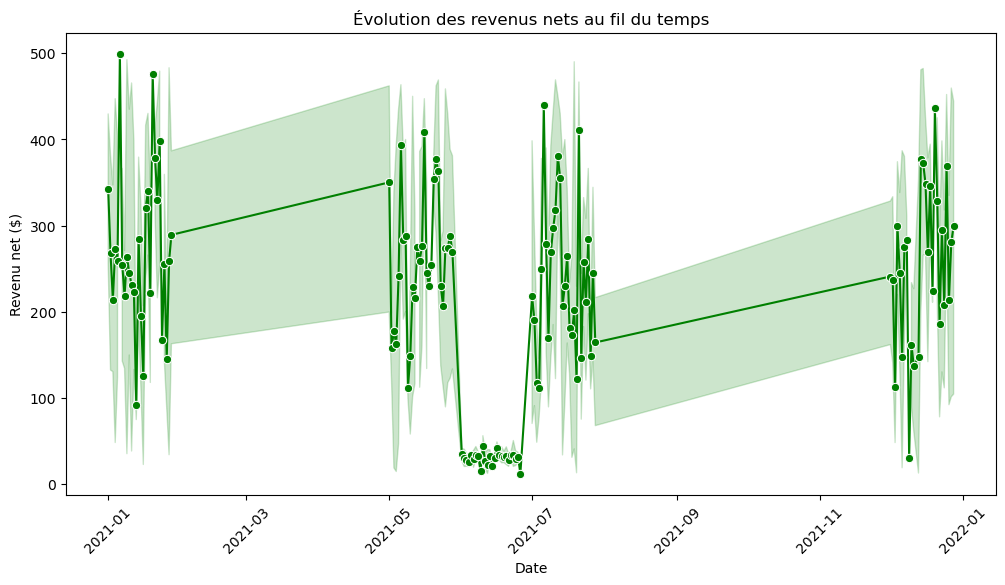

In [177]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df1, x="date", y="unit_price", marker="o", color="green")
plt.xlabel("Date")
plt.ylabel("Revenu net ($)")
plt.title("Évolution des revenus nets au fil du temps")
plt.xticks(rotation=45)
plt.show()


### Heatmap des ventes par entrepôt et mode de paiement
#### **Objectif** : 
- Analyser la corrélation entre les entrepôts et les modes de paiement.
#### **Interprétation attendue** :
- Détermine quel mode de paiement est le plus utilisé dans chaque entrepôt.
- Permet d’optimiser les options de paiement si certaines méthodes sont peu utilisées.



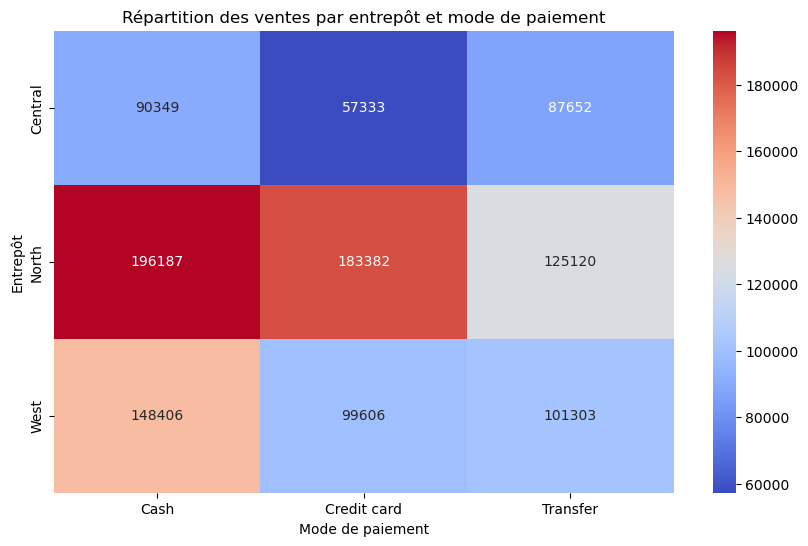

In [181]:
plt.figure(figsize=(10,6))
pivot_table = df1.pivot_table(index="warehouse", columns="payment", values="total", aggfunc="sum")
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="coolwarm")
plt.xlabel("Mode de paiement")
plt.ylabel("Entrepôt")
plt.title("Répartition des ventes par entrepôt et mode de paiement")
plt.show()


## Nuage de points (Scatter Plot) entre le prix total et la quantité commandée
### **Objectif** : 
- Voir s’il y a une relation entre le prix total des commandes et la quantité commandée.



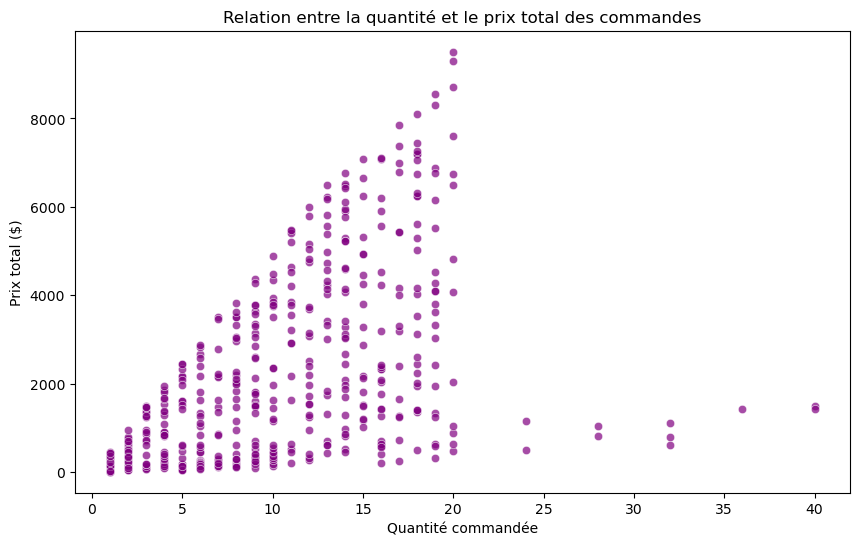

In [187]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df1, x="quantity", y="total", alpha=0.7, color="purple")
plt.xlabel("Quantité commandée")
plt.ylabel("Prix total ($)")
plt.title("Relation entre la quantité et le prix total des commandes")
plt.show()


In [171]:
print(df1.columns)


Index(['order_number', 'date', 'warehouse', 'client_type', 'product_line',
       'quantity', 'unit_price', 'total', 'payment', 'payment_fee'],
      dtype='object')
